# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# Eksperimen Machine Learning — Bank Marketing Dataset

## Perkenalan Dataset

**Sumber:** UCI Machine Learning Repository  
**Link:** https://archive.ics.uci.edu/dataset/222/bank+marketing

Dataset ini berisi data kampanye pemasaran telepon sebuah bank di Portugal. Tujuannya adalah memprediksi apakah nasabah akan berlangganan deposito berjangka (**yes/no**).

- **Jumlah data:** ±45.211 baris, 16 fitur + 1 target
- **Tipe masalah:** Klasifikasi biner
- **Target:** kolom `y` (yes = berlangganan, no = tidak)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
import requests
import zipfile
import io
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

In [3]:
csv_file_name = 'bank-additional/bank-additional-full.csv'
with zip_file.open(csv_file_name) as file:

    df = pd.read_csv(file, sep=';')

In [4]:
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.describe(include=['object'])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [8]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


Distribusi Target Variable 'y':
y
no     36548
yes     4640
Name: count, dtype: int64

Distribusi dalam Persentase:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


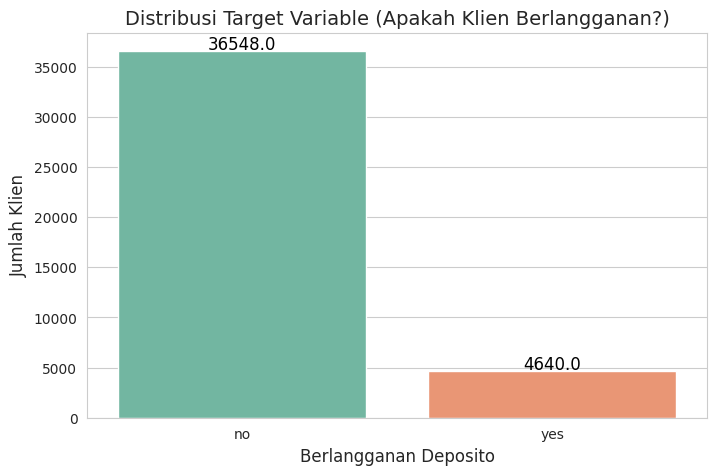

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribusi Target Variable 'y':")
print(df['y'].value_counts())
print("\nDistribusi dalam Persentase:")
print(df['y'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='y', data=df, hue='y', palette='Set2', legend=False)
plt.title('Distribusi Target Variable (Apakah Klien Berlangganan?)', fontsize=14)
plt.xlabel('Berlangganan Deposito', fontsize=12)
plt.ylabel('Jumlah Klien', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

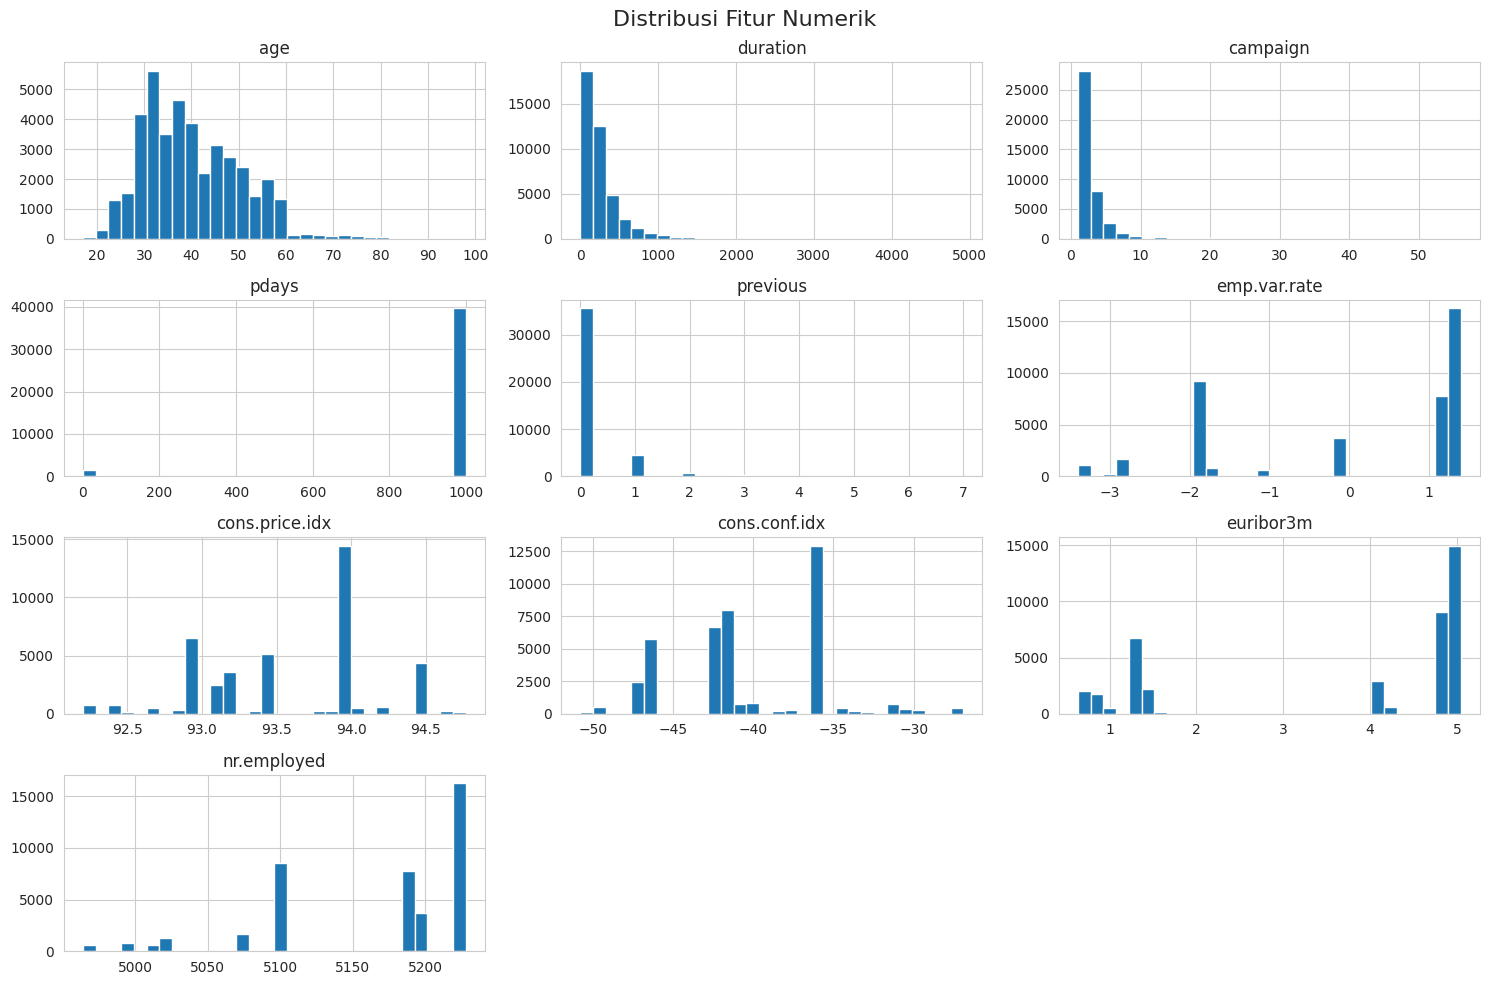

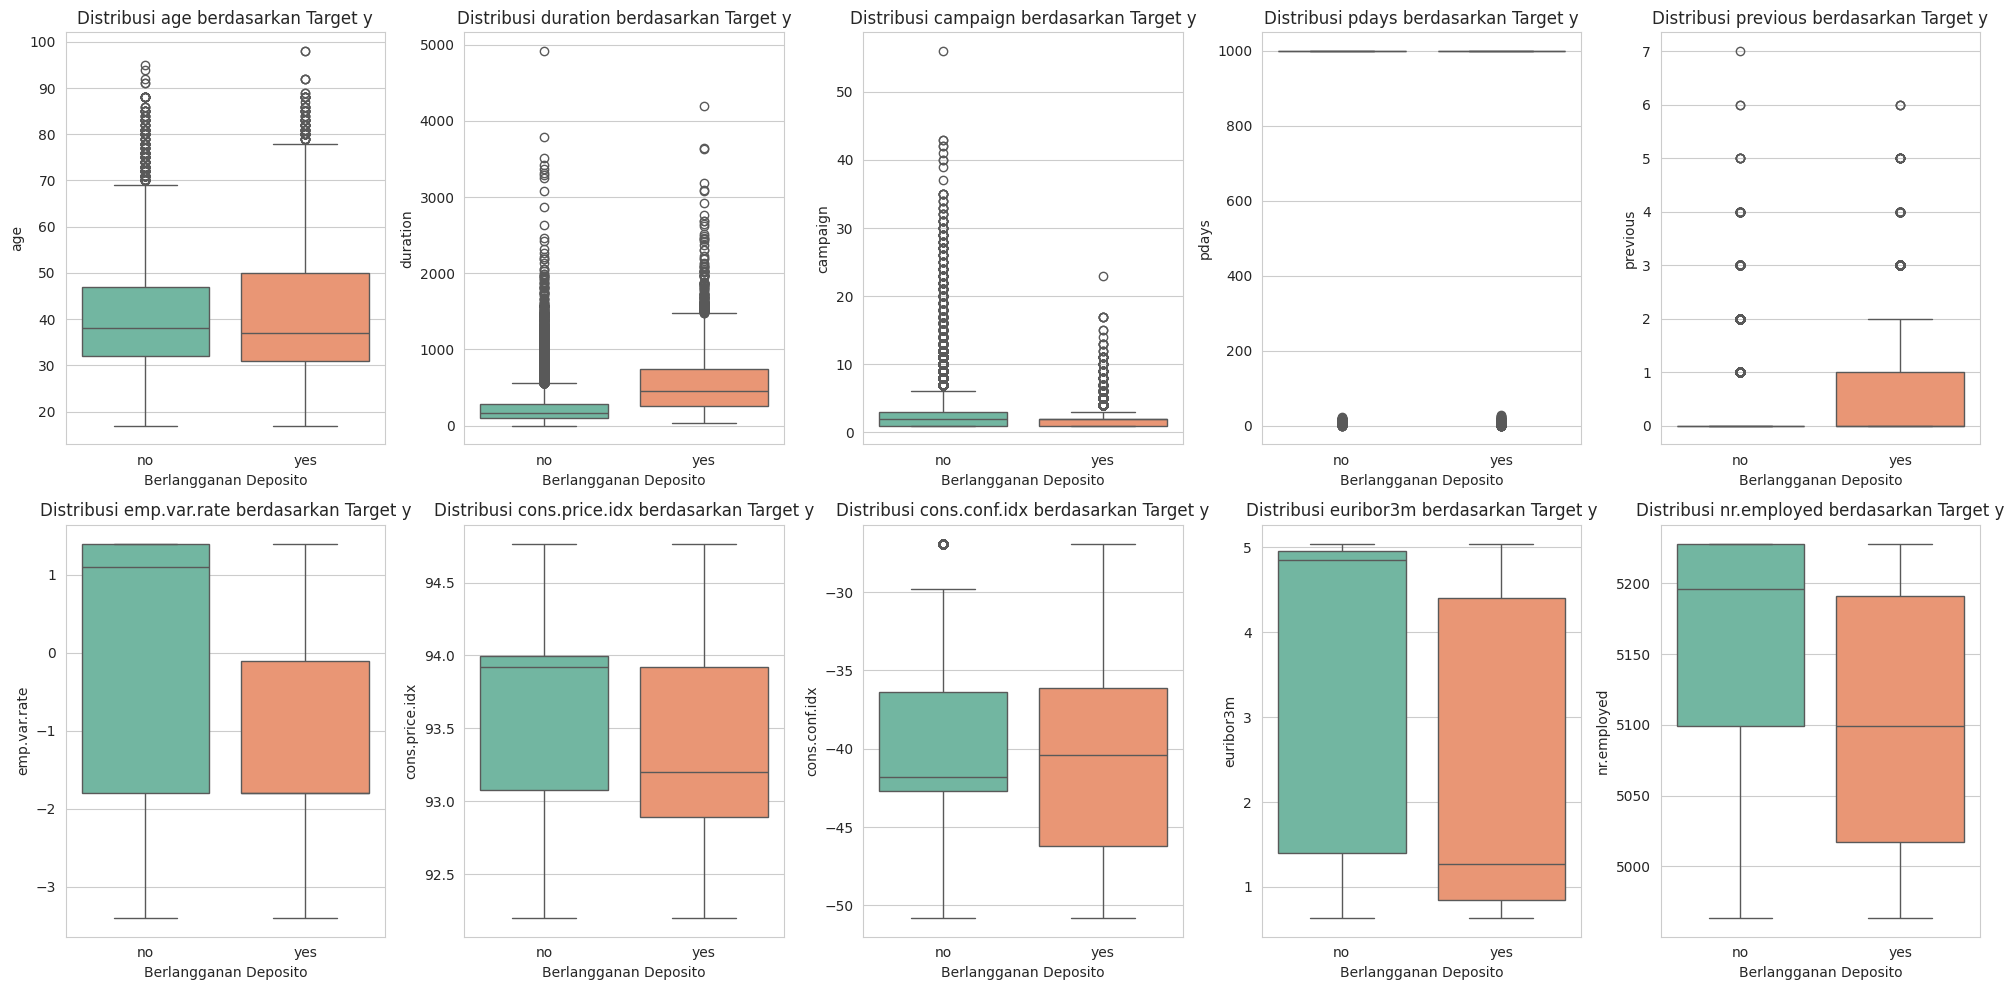

In [10]:
numeric_features = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribusi Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='y', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {feature} berdasarkan Target y')
    axes[i].set_xlabel('Berlangganan Deposito')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

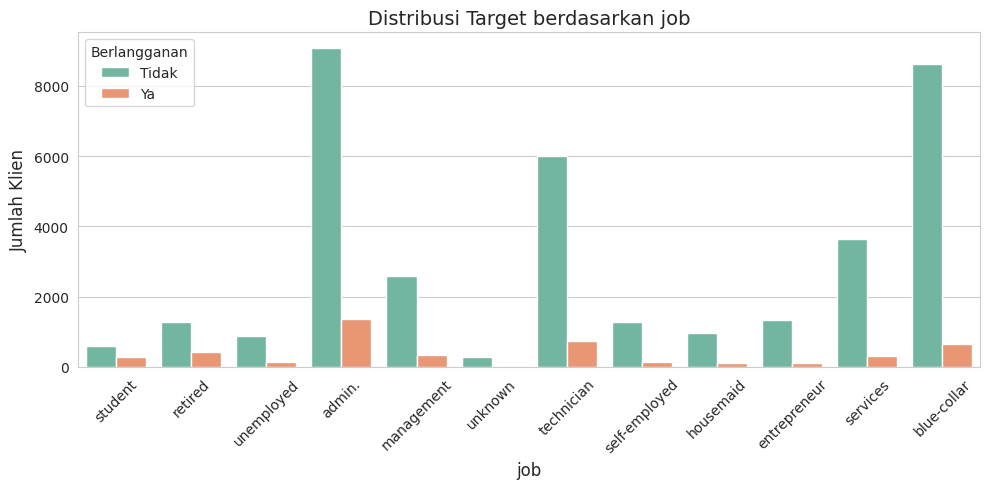

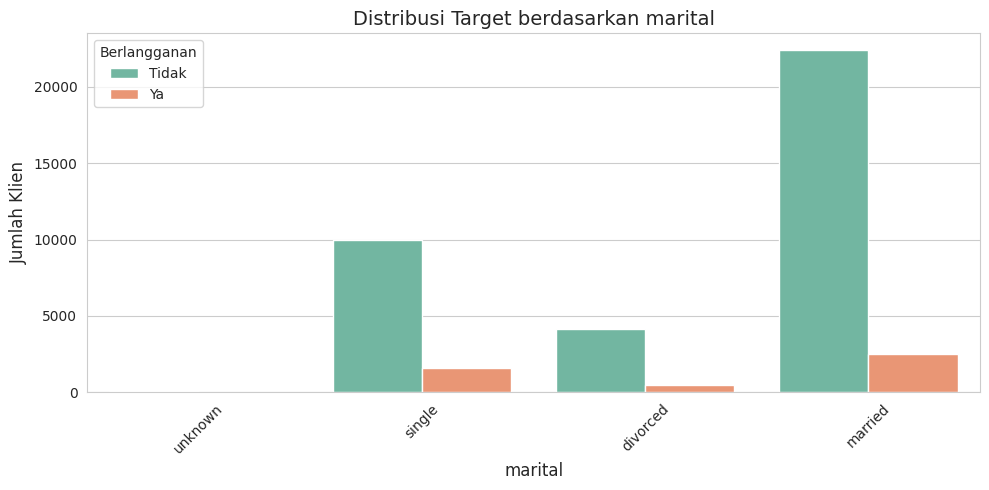

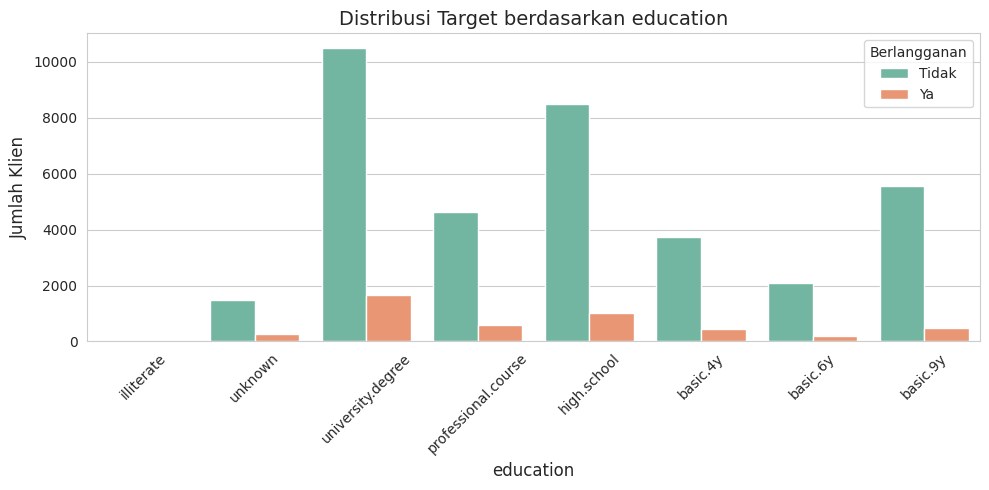

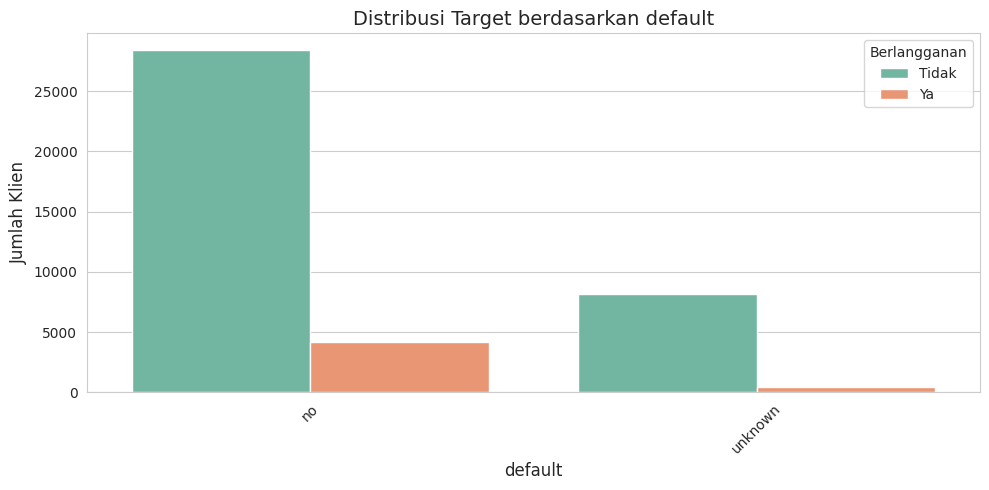

In [11]:
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                        'contact', 'month', 'day_of_week', 'poutcome']

def plot_categorical_target(feature):
    plt.figure(figsize=(10, 5))
    order = df.groupby(feature)['y'].value_counts(normalize=True).loc[:, 'yes'].sort_values(ascending=False).index
    sns.countplot(x=feature, hue='y', data=df, order=order, palette='Set2')
    plt.title(f'Distribusi Target berdasarkan {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Jumlah Klien', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Berlangganan', labels=['Tidak', 'Ya'])
    plt.tight_layout()
    plt.show()

for feature in categorical_features[:4]:
    plot_categorical_target(feature)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

df_processed = df.copy()
df_processed = df_processed.drop('duration', axis=1)
for col in categorical_features:
    if col in df_processed.columns:
        mode_val = df_processed[col].mode()[0]
        df_processed[col] = df_processed[col].replace('unknown', mode_val)

In [13]:
le = LabelEncoder()
df_processed['y'] = le.fit_transform(df_processed['y'])
df_processed = pd.get_dummies(df_processed, columns=[col for col in categorical_features if col in df_processed.columns], drop_first=True)

In [14]:
X = df_processed.drop('y', axis=1)
y = df_processed['y']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Jumlah data training setelah SMOTE: {X_train_resampled.shape}")
print(f"Distribusi kelas setelah SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

Jumlah data training setelah SMOTE: (58476, 46)
Distribusi kelas setelah SMOTE:
y
0    29238
1    29238
Name: count, dtype: int64


In [17]:

scaler = StandardScaler()

original_numeric_features = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                             'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

available_numeric = [f for f in original_numeric_features if f in X_train_resampled.columns]

X_train_resampled[available_numeric] = scaler.fit_transform(X_train_resampled[available_numeric])
X_test[available_numeric] = scaler.transform(X_test[available_numeric])

print("Data preprocessing selesai!")

Data preprocessing selesai!


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [21]:
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Tidak Berlangganan', 'Berlangganan']))

Laporan Klasifikasi:
                    precision    recall  f1-score   support

Tidak Berlangganan       0.93      0.94      0.94      7310
      Berlangganan       0.48      0.40      0.44       928

          accuracy                           0.88      8238
         macro avg       0.70      0.67      0.69      8238
      weighted avg       0.88      0.88      0.88      8238



In [22]:
print("\nAkurasi:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))


Akurasi: 0.8834668608885652
AUC-ROC: 0.7704373584838906


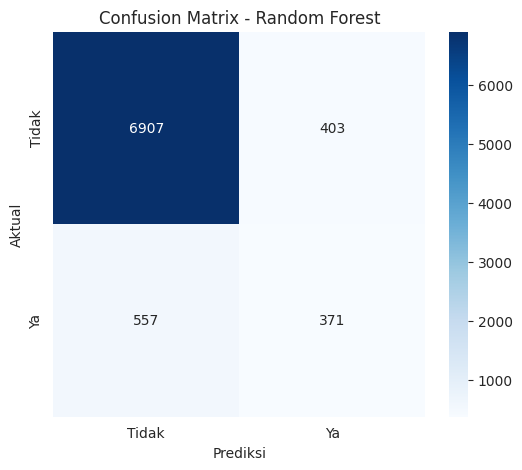

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak', 'Ya'], yticklabels=['Tidak', 'Ya'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()


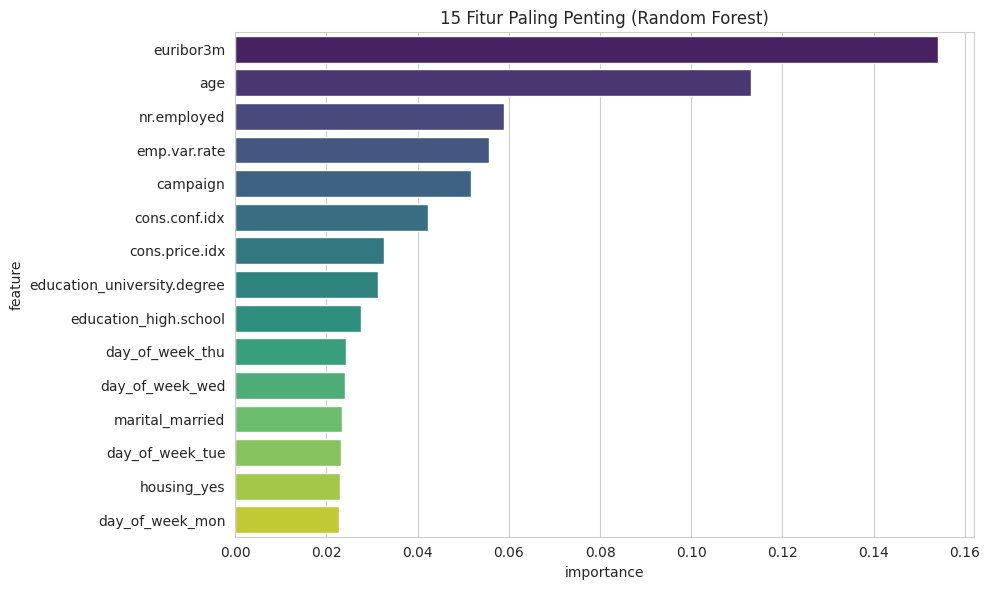

In [24]:
importances = rf_model.feature_importances_
features = X_train_resampled.columns
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', hue='feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title('15 Fitur Paling Penting (Random Forest)')
plt.tight_layout()
plt.show()

In [25]:
import os
import joblib

os.makedirs('preprocessed_data', exist_ok=True)

X_train_resampled.to_csv('preprocessed_data/X_train_preprocessed.csv', index=False)
X_test.to_csv('preprocessed_data/X_test_preprocessed.csv', index=False)

pd.Series(y_train_resampled).to_csv('preprocessed_data/y_train_preprocessed.csv', index=False, header=False)
pd.Series(y_test).to_csv('preprocessed_data/y_test_preprocessed.csv', index=False, header=False)

joblib.dump(scaler, 'preprocessed_data/scaler.pkl')
joblib.dump(le, 'preprocessed_data/label_encoder_y.pkl')

print("✅ Data preprocessed berhasil disimpan ke folder 'preprocessed_data'")
print("Daftar file yang tersimpan:")
for f in os.listdir('preprocessed_data'):
    print(f" - {f}")

✅ Data preprocessed berhasil disimpan ke folder 'preprocessed_data'
Daftar file yang tersimpan:
 - y_train_preprocessed.csv
 - X_train_preprocessed.csv
 - X_test_preprocessed.csv
 - scaler.pkl
 - label_encoder_y.pkl
 - y_test_preprocessed.csv
